In [25]:
# <<<< 데이터 포장 >>>>

# 1. 시스템 및 파일 관리
import os
import glob
import random

# 2. 데이터 분석 및 행렬 연산
import numpy as np
import pandas as pd

# 3. 시각화 및 이미지 처리
import cv2
import matplotlib.pyplot as plt
from PIL import Image

# 4. 머신러닝/딥러닝 프레임워크 (PyTorch)
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models

# 5. 성능 평가 및 데이터 분리
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

csv_path = '/kaggle/input/landmark-recognition-2020-128x128/landmark_recognition_128/train.csv'
train_df = pd.read_csv(csv_path)

# 6. 환경 확인
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"현재 사용 중인 장치: {device}") # GPU가 잡혀야 학습이 빠릅니다.

# ==========================================
# [수정된 데이터 포장] "유명한 Top 10 랜드마크만 골라내기"
# ==========================================

# 1. 데이터가 가장 많은 상위 10개 랜드마크 ID 추출
top_n = 10 
top_landmark_ids = train_df['landmark_id'].value_counts().nlargest(top_n).index

# 2. 해당 랜드마크 데이터만 필터링 (이제 같은 랜드마크 사진이 여러 장 모입니다)
train_sample = train_df[train_df['landmark_id'].isin(top_landmark_ids)].copy().reset_index(drop=True)

# (옵션) 데이터가 너무 많으면 학습 속도를 위해 2000개까지만 줄임
if len(train_sample) > 2000:
    train_sample = train_sample.sample(n=2000, random_state=42).reset_index(drop=True)

print(f"선택된 데이터 개수: {len(train_sample)}개")

# 3. 라벨 압축 (Label Remapping) - 0~9번으로 다시 번호 매기기
unique_labels = train_sample['landmark_id'].unique()
label_map = {raw_id: idx for idx, raw_id in enumerate(unique_labels)}
train_sample['label_idx'] = train_sample['landmark_id'].map(label_map) 

# 4. 클래스 개수 저장
num_classes = len(unique_labels)
print(f"총 클래스 개수(num_classes): {num_classes}")

# 5. 데이터 분리 (Stratify 옵션 추가)
# stratify=... : 훈련/검증 셋에 정답 비율을 똑같이 맞춰줍니다 (중요!)
train_data, val_data = train_test_split(train_sample, 
                                        test_size=0.2, 
                                        random_state=42, 
                                        stratify=train_sample['label_idx'])

# ★★★ __init__, __len__, __getitem__ 는 파이토치에서 커스템 데이터셋 만들 떄 반드시 지켜야할 약속임
class LandmarkDataset(Dataset) :
    # init은 getitem을 위한 사전 준비, len은 getitem을 위한 범위 제한
    def __init__(self, df, transform=None):
        self.df = df
        # [수정] 스크린샷 경로 반영: 중간 폴더 포함해서 'train 폴더'까지 지정
        self.base_dir = '/kaggle/input/landmark-recognition-2020-128x128/landmark_recognition_128/train'
        self.transform = transform

    def __len__(self) :
        return len(self.df)

    def __getitem__(self, idx) : #실질적 실행자
        # 1. CSV(리스트)에서 정보 꺼내기
        row = self.df.iloc[idx]
        img_id = row['id']
        label = row['label_idx'] # 아까 만든 압축 라벨 사용
        
        # 2. 창고(base_dir)에서 실제 이미지 경로 만들기
        # (이미지가 a/b/c/abc.jpg 처럼 깊게 들어있어서 이렇게 찾습니다)
        img_path = os.path.join(self.base_dir, img_id[0], img_id[1], img_id[2], f"{img_id}.jpg")

        image = Image.open(img_path).convert('RGB')
        if self.transform:
            image = self.transform(image)
            
        return image, torch.tensor(label, dtype=torch.long)

transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

train_loader = DataLoader(LandmarkDataset(train_data, transform), batch_size=32, shuffle=True)
val_loader = DataLoader(LandmarkDataset(val_data, transform), batch_size = 32, shuffle=False)


현재 사용 중인 장치: cuda
선택된 데이터 개수: 2000개
총 클래스 개수(num_classes): 10


In [26]:
# <<<< 모델 설계 >>>>
# SimpleCNN -> Resnet-18 변경
from torchvision import models

# weights='DEFAULT'는 현재 PyTorch에서 사용 가능한 가장 성능 좋은 가중치를 자동으로 가져옴
model = models.resnet18(weights='DEFAULT')

# ResNet-18 규격상 512가 반환되나, 
# 모델 변경 시에도 대응 가능한 유연한 구조위해 아래 템플릿 활용
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, num_classes) # (512 -> 10)

# GPU/CPU 장비 할당
model = model.to(device)

print("모델 교체 완료: SimpleCNN => ResNet-18")

모델 교체 완료: SimpleCNN => ResNet-18


In [27]:
# <<<< 학습 루프 >>>>
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001) # 0.001 -> 0.0001

num_epochs = 10

print(f"학습 시작! (총 클래스 개수: {num_classes})")

for epoch in range(num_epochs) :
    model.train() # 학습모드 on
    running_loss = 0.0

    # train
    for inputs, labels in train_loader : 
        inputs, labels = inputs.to(device), labels.to(device) 

        optimizer.zero_grad() # 1. 기울기 초기화
        outputs = model(inputs) # 2. 예측
        loss = criterion(outputs, labels) # 3. 오차 계산
        loss.backward() # 4. 역전파 (오답 노트)
        optimizer.step() # 5. 가중치 갱신 (공부)

        running_loss += loss.item()

    print(f"Epoch [{epoch+1}/{num_epochs}] Loss: {running_loss/len(train_loader):.4f}")

학습 시작! (총 클래스 개수: 10)
Epoch [1/10] Loss: 0.7564
Epoch [2/10] Loss: 0.1240
Epoch [3/10] Loss: 0.0331
Epoch [4/10] Loss: 0.0159
Epoch [5/10] Loss: 0.0097
Epoch [6/10] Loss: 0.0074
Epoch [7/10] Loss: 0.0056
Epoch [8/10] Loss: 0.0041
Epoch [9/10] Loss: 0.0049
Epoch [10/10] Loss: 0.0033



[최종 평가] 학습된 모델로 최종 성능을 측정합니다...
🏆 최종 모델 정확도: 95.00%


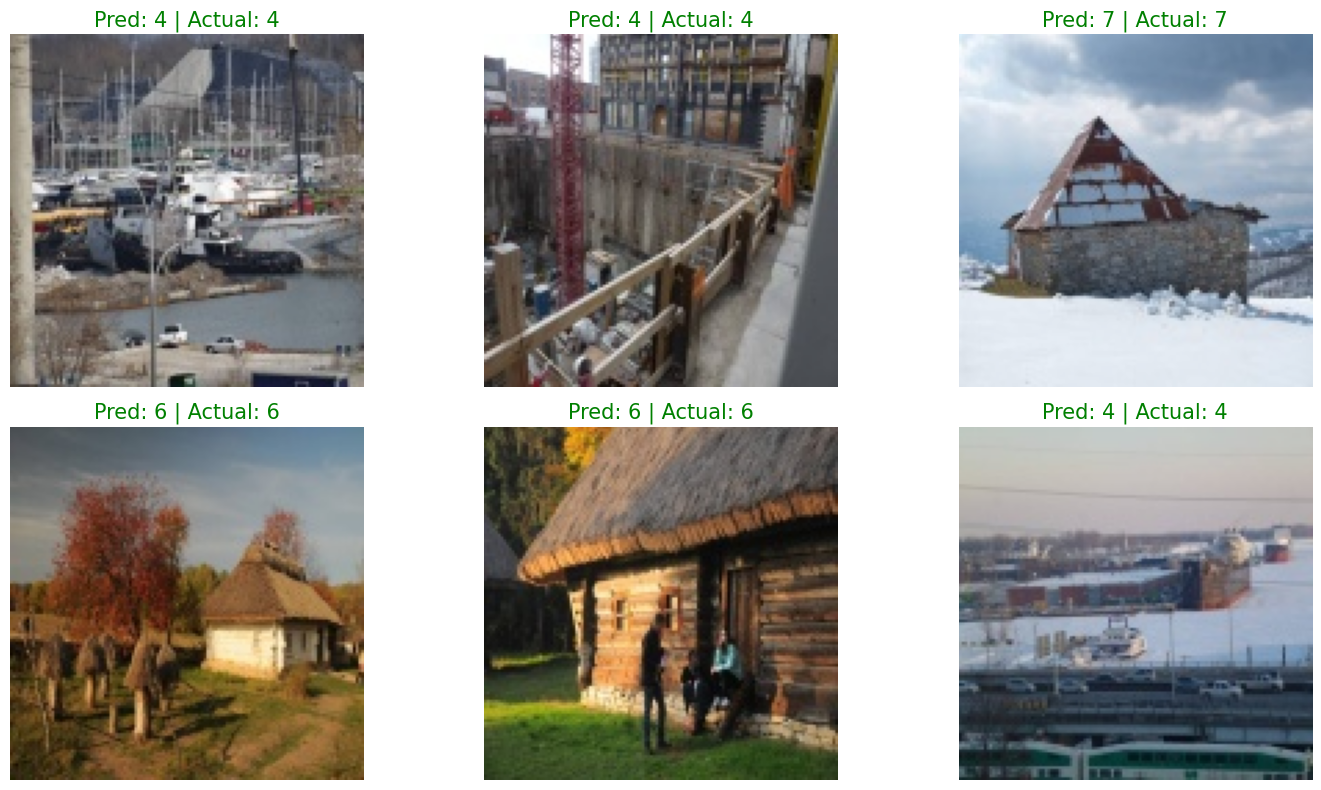

In [28]:
# <<<< 최종 평가 (Evaluation) >>>> 

print("\n[최종 평가] 학습된 모델로 최종 성능을 측정합니다...")

# 1. 평가 모드 전환 (필수!)
model.eval() 

correct = 0
total = 0
all_labels = []
all_preds = []

# 2. 평가 진행 (기울기 계산 X)
with torch.no_grad():
    for inputs, labels in val_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        
        # 모델 예측
        outputs = model(inputs)
        
        # 가장 높은 확률의 정답 선택
        _, predicted = torch.max(outputs.data, 1)
        
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        
        # 나중에 혼동 행렬(Confusion Matrix) 등을 그리려면 저장해둠
        all_labels.extend(labels.cpu().numpy())
        all_preds.extend(predicted.cpu().numpy())

# 3. 최종 결과 출력
final_acc = 100 * correct / total
print(f"===========================================")
print(f"🏆 최종 모델 정확도: {final_acc:.2f}%")
print(f"===========================================")

# <<<< 시각화 (눈으로 확인하기) >>>>
def visualize_predictions(model, loader, num_images=6):
    model.eval()
    images, labels = next(iter(loader)) # 배치를 하나 가져옵니다
    images, labels = images.to(device), labels.to(device)

    with torch.no_grad():
        outputs = model(images)
        _, preds = torch.max(outputs, 1)

    # 시각화를 위한 설정
    plt.figure(figsize=(15, 8))
    
    for i in range(num_images):
        plt.subplot(2, 3, i+1)
        
        # Tensor -> Numpy 변환 및 차원 순서 변경 (C, H, W) -> (H, W, C)
        img = images[i].cpu().numpy().transpose((1, 2, 0))
        
        # Normalize 했던 것을 원상복구 (화면 출력용)
        mean = np.array([0.485, 0.456, 0.406])
        std = np.array([0.229, 0.224, 0.225])
        img = std * img + mean
        img = np.clip(img, 0, 1) # 0~1 사이 값으로 제한

        plt.imshow(img)
        
        # 정답이면 초록색, 오답이면 빨간색 제목
        color = 'green' if preds[i] == labels[i] else 'red'
        plt.title(f"Pred: {preds[i]} | Actual: {labels[i]}", color=color, fontsize=15)
        plt.axis('off')
    
    plt.tight_layout()
    plt.show()

# 실행
visualize_predictions(model, val_loader)